<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 2</h3>
    <h3>Ejercicio 3</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno y Braian Drago<p>
</div>

https://www.estadisticaciudad.gob.ar/eyc/?p=27702

In [ ]:
# !pip install pmdarima
!pip install numpy==1.26.4 pandas==2.2.2 statsmodels==0.14.4 pmdarima==2.0.4  # Primero
!pip install scipy==1.13.1  # Segundo


In [ ]:
from pmdarima import auto_arima

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARMA
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
#from pmdarima.arima.utils import ndiffs
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
from itertools import product

In [ ]:
def Augmented_Dickey_Fuller_Test_func(series , column_name):
  print (f'Results of Dickey-Fuller Test for column: {column_name}')
  dftest = adfuller(series, autolag='AIC')
  dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of Observations Used'])
  for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
  print (dfoutput)
  if dftest[1] <= 0.05:
    print("Conclusion:====>")
    print("Reject the null hypothesis")
    print("Data is stationary")
  else:
    print("Conclusion:====>")
    print("Fail to reject the null hypothesis")
    print("Data is non-stationary")

In [ ]:
url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/MA_AX01%20.csv'
datatemperatura = pd.read_csv(url)

In [ ]:
print(datatemperatura.head())

            Media  Maxima  Minima
Dias                             
1991-01-31   24.0    28.4    19.8
1991-02-28   22.9    27.8    17.8
1991-03-31   22.7    27.6    18.4
1991-04-30   17.8    22.4    13.6
1991-05-31   16.0    20.7    12.2


In [ ]:
date_range = pd.date_range(start='1991-01-01', end='2024-04-30', freq='M')

df = pd.DataFrame({'Date': date_range})

print(df.head())
print(df.tail())

        Date
0 1991-01-31
1 1991-02-28
2 1991-03-31
3 1991-04-30
4 1991-05-31
          Date
395 2023-12-31
396 2024-01-31
397 2024-02-29
398 2024-03-31
399 2024-04-30


/tmp/ipykernel_675/3795233049.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start='1991-01-01', end='2024-04-30', freq='M')


In [ ]:
datatemperatura['Dias'] = date_range

In [ ]:
print(datatemperatura.tail())

            Media  Maxima  Minima
Dias                             
2023-12-31   23.1    27.7    18.4
2024-01-31   25.5    30.2    21.4
2024-02-29   26.0    30.5    22.1
2024-03-31   22.9    27.4    19.2
2024-04-30   18.7    22.6    14.9


In [ ]:
print(datatemperatura.dtypes)

Media     float64
Maxima    float64
Minima    float64
dtype: object


In [ ]:
datatemperatura.index = datatemperatura['Dias']
del datatemperatura['Fecha']
del datatemperatura['Dias']

In [ ]:
print(datatemperatura.index.dtype)

datetime64[ns]


In [ ]:
print(datatemperatura.head())

            Media  Maxima  Minima
Dias                             
1991-01-31   24.0    28.4    19.8
1991-02-28   22.9    27.8    17.8
1991-03-31   22.7    27.6    18.4
1991-04-30   17.8    22.4    13.6
1991-05-31   16.0    20.7    12.2


<Axes: xlabel='Dias'>

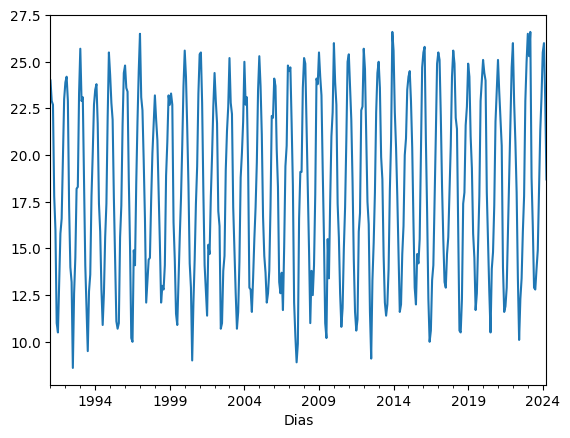

In [ ]:
datatemperatura.Media.plot()

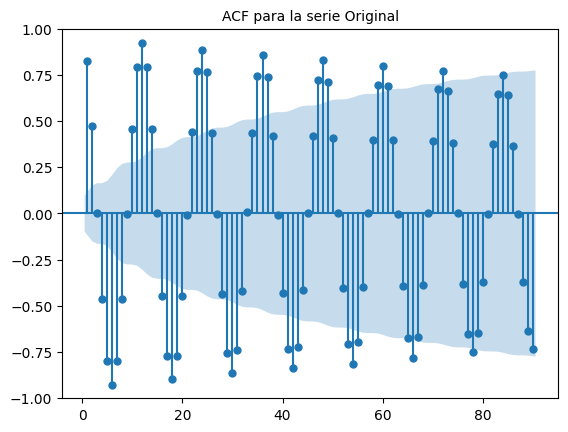

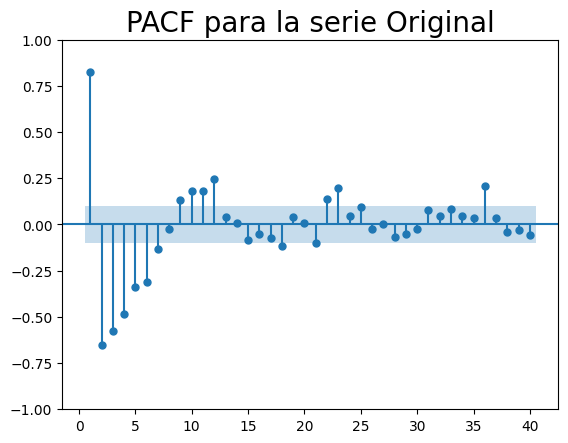

In [ ]:
sgt.plot_acf(datatemperatura.Media , zero = False, lags = 90)
plt.title("ACF para la serie Original", size = 10)
plt.show()

sgt.plot_pacf(datatemperatura.Media, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF para la serie Original", size = 20)
plt.show()

En el grafico ACF se ve una posible estacionalidad, con un patron que se se repite cada 12 periodos.

In [ ]:
len(datatemperatura)

400

In [ ]:
X = datatemperatura[['Media']]
train, test = X[0:-24], X[-24:]
X.head()

,Media
Dias,
1991-01-31,24.0
1991-02-28,22.9
1991-03-31,22.7
1991-04-30,17.8
1991-05-31,16.0


A continuacion hacemos diferentes transformaciones de la serie original

# Primera = Promedio móvil de 7 días.

In [ ]:
datatemperatura_prom_mov = datatemperatura.copy()
datatemperatura_prom_mov['promedio_movil_7'] = datatemperatura_prom_mov['Media'].rolling(window=7).mean()


In [ ]:
datatemperatura_prom_mov.head(12)

,Media,Maxima,Minima,promedio_movil_7
Dias,,,,
1991-01-31,24.0,28.4,19.8,NaN
1991-02-28,22.9,27.8,17.8,NaN
1991-03-31,22.7,27.6,18.4,NaN
1991-04-30,17.8,22.4,13.6,NaN
1991-05-31,16.0,20.7,12.2,NaN
1991-06-30,11.0,14.8,7.6,NaN
1991-07-31,10.5,14.8,6.7,17.842857
1991-08-31,13.2,17.1,9.3,16.300000
1991-09-30,15.8,20.5,11.7,15.285714


In [ ]:
indices_a_eliminar = ['1991-01-31','1991-02-28','1991-03-31','1991-04-30','1991-05-31','1991-06-30']

datatemperatura_prom_mov = datatemperatura_prom_mov.drop(indices_a_eliminar)

In [ ]:
datatemperatura_prom_mov.head(12)

,Media,Maxima,Minima,promedio_movil_7
Dias,,,,
1991-07-31,10.5,14.8,6.7,17.842857
1991-08-31,13.2,17.1,9.3,16.300000
1991-09-30,15.8,20.5,11.7,15.285714
1991-10-31,16.6,21.1,12.2,14.414286
1991-11-30,19.7,24.3,15.3,14.685714
1991-12-31,23.0,27.8,18.7,15.685714
1992-01-31,23.9,28.5,19.8,17.528571
1992-02-29,24.2,29.0,19.8,19.485714
1992-03-31,22.9,27.4,18.9,20.871429


<Axes: xlabel='Dias'>

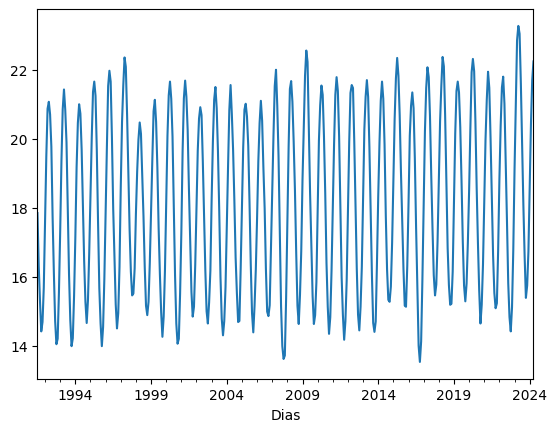

In [ ]:
datatemperatura_prom_mov.promedio_movil_7.plot()

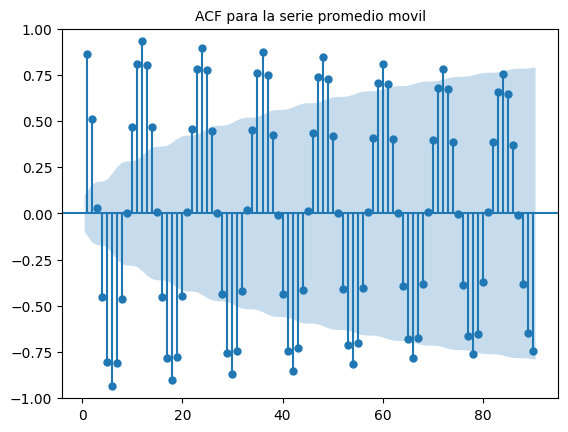

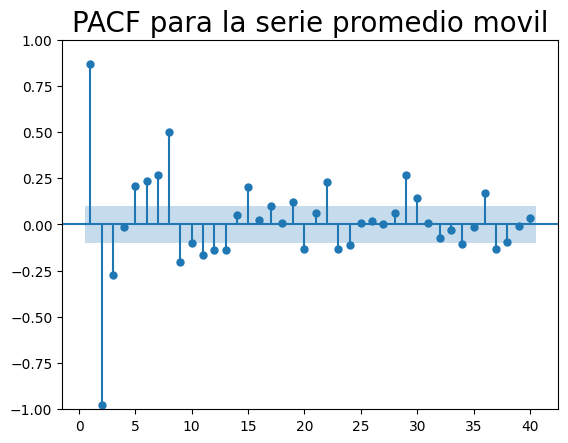

In [ ]:
sgt.plot_acf(datatemperatura_prom_mov.promedio_movil_7 , zero = False, lags = 90)
plt.title("ACF para la serie promedio movil", size = 10)
plt.show()

sgt.plot_pacf(datatemperatura_prom_mov.promedio_movil_7, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF para la serie promedio movil", size = 20)
plt.show()

En la ACF vemos que cuando aplicamos un promedio movil de 7 dias a la serie original reducimos el ruido aleatorio y asi resaltamos con mas claridad la estructura de autocorrelacion ciclica de la serie. Este patron estacional que se veia en la ACF de los datos original se mantiene e incluso se vuelve + marcado mostrando que la estacionalidad subyacente persiste tras la suavizacion. Esto confirma que el componente estacional no es un artefacto del ruido sino una caracteristica estructural del proceso

# Segunda transformacion = quitarle el componente estacional

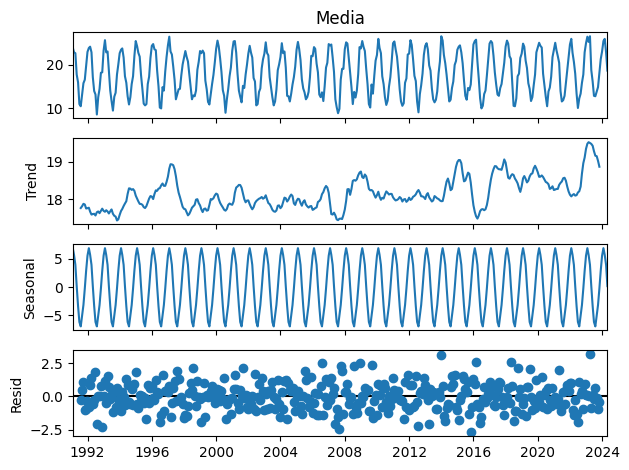

In [ ]:
# Aca por el codigo que usamos recomendamos ver que tipo de modelo de descomposicion tiene ( aditivo o multiplicativo), entonces vemos codigos de la clase 1
# Van comentarios extras en el codigo.

result = seasonal_decompose(datatemperatura['Media'], model='additive', period=12) # En modelo hay q probar additive o multiplicative

'''
"period=12"  En esta serie los datos son mensuales entonces el parametro period tiene que reflejar eso. En series mensuales tipicas un ciclo anual tiene 12 observaciones.
'''

result.plot()
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

datatemperatura_3 = datatemperatura.copy()
result = seasonal_decompose(datatemperatura_3['Media'], model='additive', period=12)
datatemperatura_3['deseasonalizada'] = datatemperatura_3['Media'] - result.seasonal

# Codigo opcional
datatemperatura_3.dropna(inplace=True)

In [ ]:
datatemperatura_3.head()

,Media,Maxima,Minima,deseasonalizada
Dias,,,,
1991-01-31,24.0,28.4,19.8,17.117464
1991-02-28,22.9,27.8,17.8,17.196370
1991-03-31,22.7,27.6,18.4,18.777360
1991-04-30,17.8,22.4,13.6,17.637646
1991-05-31,16.0,20.7,12.2,19.369938


<Axes: xlabel='Dias'>

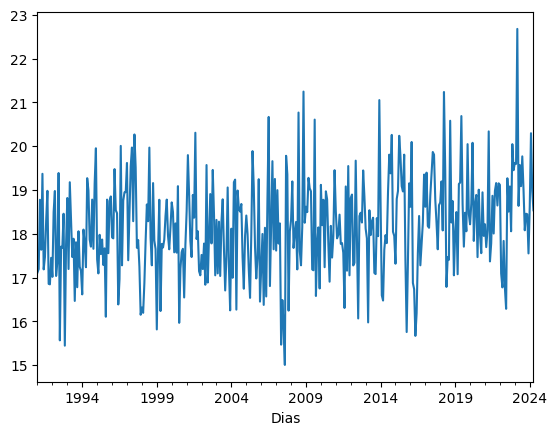

In [ ]:
datatemperatura_3.deseasonalizada.plot()

In [ ]:
X_3 = datatemperatura_3[['deseasonalizada' ]]
train_3, test_3 = X_3[0:-24], X_3[-24:]
X_3.head()

,deseasonalizada
Dias,
1991-01-31,17.117464
1991-02-28,17.196370
1991-03-31,18.777360
1991-04-30,17.637646
1991-05-31,19.369938


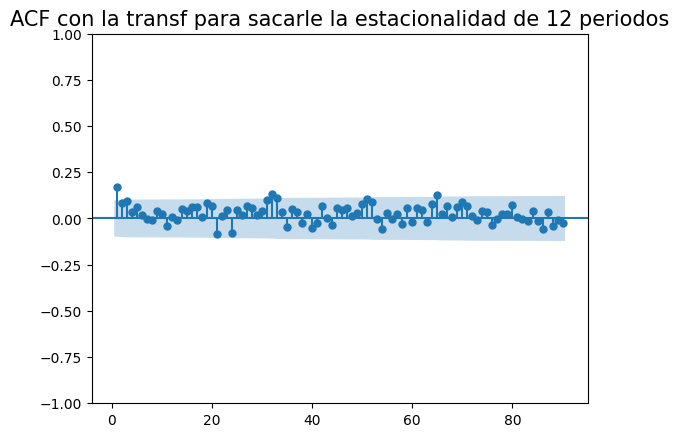

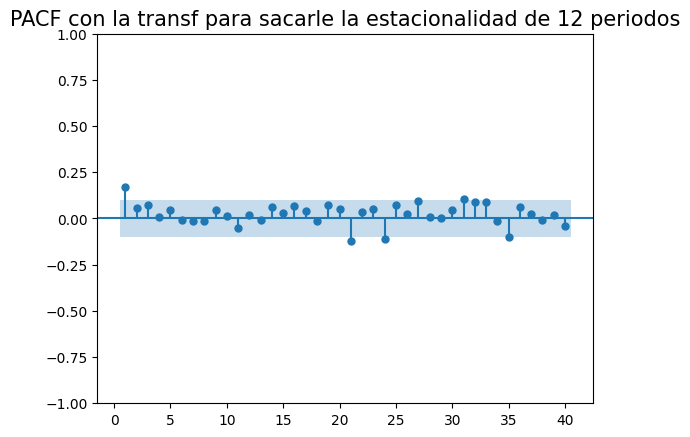

In [ ]:
sgt.plot_acf(datatemperatura_3.deseasonalizada , zero = False, lags = 90)
plt.title("ACF con la transf para sacarle la estacionalidad de 12 periodos", size = 15)
plt.show()

sgt.plot_pacf(datatemperatura_3.deseasonalizada, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF con la transf para sacarle la estacionalidad de 12 periodos", size = 15)
plt.show()

# Tercer transformacion = diferenciacion de la serie ya deseasonalizada

In [ ]:
datatemperatura_4 = datatemperatura_3.copy()
datatemperatura_4['deseasonalizada'] = datatemperatura_4['deseasonalizada'].diff()

In [ ]:
datatemperatura_4.head(7)

,Media,Maxima,Minima,deseasonalizada
Dias,,,,
1991-01-31,24.0,28.4,19.8,NaN
1991-02-28,22.9,27.8,17.8,0.078906
1991-03-31,22.7,27.6,18.4,1.580990
1991-04-30,17.8,22.4,13.6,-1.139714
1991-05-31,16.0,20.7,12.2,1.732292
1991-06-30,11.0,14.8,7.6,-2.182161
1991-07-31,10.5,14.8,6.7,0.280165


In [ ]:
indices_a_eliminar = ['1991-01-31']

datatemperatura_4 = datatemperatura_4.drop(indices_a_eliminar)

In [ ]:
datatemperatura_4.head(4)

,Media,Maxima,Minima,deseasonalizada
Dias,,,,
1991-02-28,22.9,27.8,17.8,0.078906
1991-03-31,22.7,27.6,18.4,1.580990
1991-04-30,17.8,22.4,13.6,-1.139714
1991-05-31,16.0,20.7,12.2,1.732292


In [ ]:
X_4 = datatemperatura_4[['deseasonalizada' ]]
train_4, test_4 = X_4[0:-24], X_4[-24:]
X_4.head()

,deseasonalizada
Dias,
1991-02-28,0.078906
1991-03-31,1.580990
1991-04-30,-1.139714
1991-05-31,1.732292
1991-06-30,-2.182161


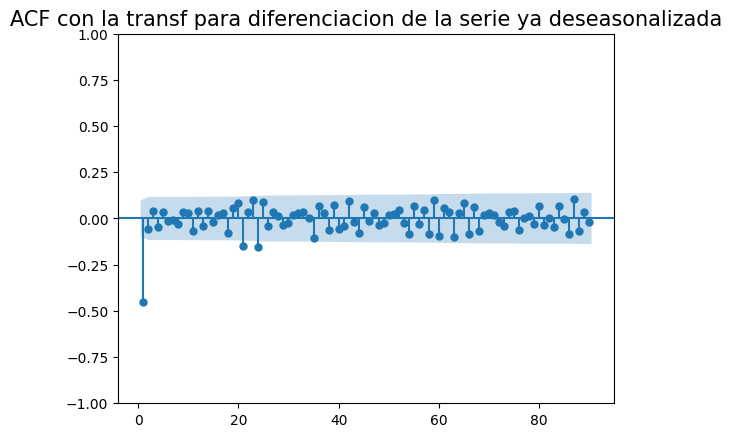

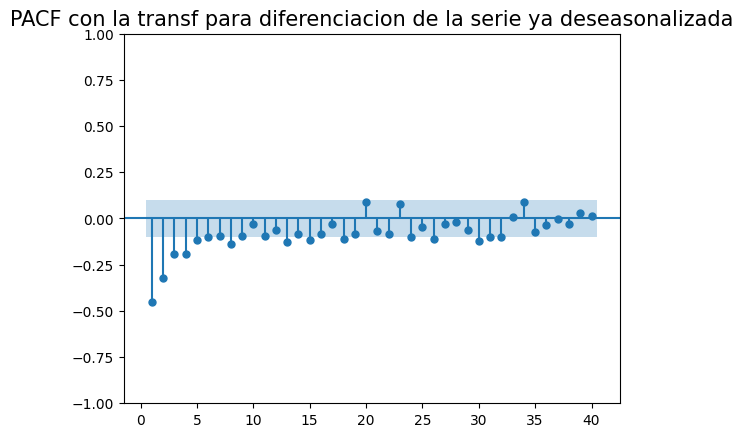

In [ ]:
sgt.plot_acf(datatemperatura_4.deseasonalizada , zero = False, lags = 90)
plt.title("ACF con la transf para diferenciacion de la serie ya deseasonalizada", size = 15)
plt.show()

sgt.plot_pacf(datatemperatura_4.deseasonalizada, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF con la transf para diferenciacion de la serie ya deseasonalizada", size = 15)
plt.show()

# Cuarta transformacion = diferenciacion

In [ ]:
# Aplicar diferenciación
datatemperatura_dif = datatemperatura.copy()
datatemperatura_dif['Valor_Dif'] = datatemperatura_dif['Media'].diff()

In [ ]:
datatemperatura_dif.head(2)

,Media,Maxima,Minima,Valor_Dif
Dias,,,,
1991-01-31,24.0,28.4,19.8,NaN
1991-02-28,22.9,27.8,17.8,-1.1


In [ ]:
indices_a_eliminar = ['1991-01-31']

datatemperatura_dif = datatemperatura_dif.drop(indices_a_eliminar)

In [ ]:
X_diff = datatemperatura_dif[['Valor_Dif' ]]
train_diff, test_diff = X_diff[0:-24], X_diff[-24:]
X_diff.head()

,Valor_Dif
Dias,
1991-02-28,-1.1
1991-03-31,-0.2
1991-04-30,-4.9
1991-05-31,-1.8
1991-06-30,-5.0


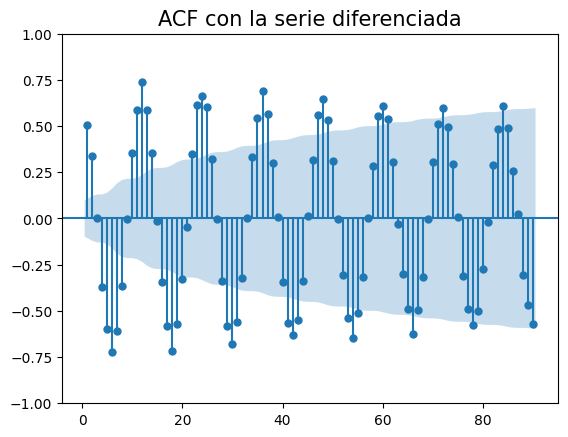

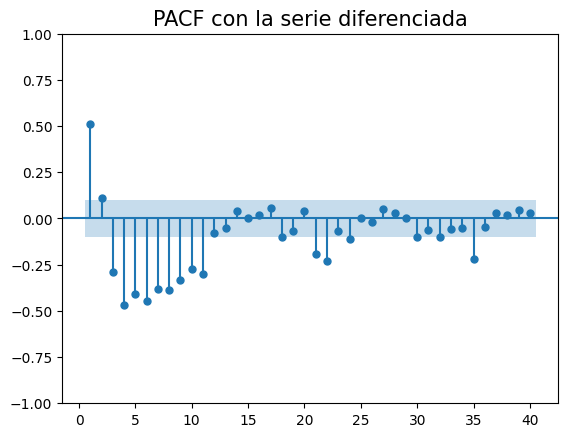

In [ ]:
sgt.plot_acf(datatemperatura_dif.Valor_Dif , zero = False, lags = 90)
plt.title("ACF con la serie diferenciada", size = 15)
plt.show()

sgt.plot_pacf(datatemperatura_dif.Valor_Dif, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF con la serie diferenciada", size = 15)
plt.show()

# Quinta transformacion = Promedios Móviles


In [ ]:
datatemperatura_prom_mov = datatemperatura.copy()

datatemperatura_prom_mov['rolling_mean'] = datatemperatura_prom_mov['Media'].rolling(window=6).mean()

# Puedes restar el promedio móvil de los datos originales para eliminar la estacionalidad
datatemperatura_prom_mov['deseasonalized'] = datatemperatura_prom_mov['Media'] - datatemperatura_prom_mov['rolling_mean']


In [ ]:
datatemperatura_prom_mov.head(7)

,Media,Maxima,Minima,rolling_mean,deseasonalized
Dias,,,,,
1991-01-31,24.0,28.4,19.8,NaN,NaN
1991-02-28,22.9,27.8,17.8,NaN,NaN
1991-03-31,22.7,27.6,18.4,NaN,NaN
1991-04-30,17.8,22.4,13.6,NaN,NaN
1991-05-31,16.0,20.7,12.2,NaN,NaN
1991-06-30,11.0,14.8,7.6,19.066667,-8.066667
1991-07-31,10.5,14.8,6.7,16.816667,-6.316667


In [ ]:
indices_a_eliminar = ['1991-01-31'	,'1991-02-28','1991-03-31','1991-04-30','1991-05-31']


datatemperatura_prom_mov = datatemperatura_prom_mov.drop(indices_a_eliminar)

In [ ]:
datatemperatura_prom_mov.head()

,Media,Maxima,Minima,rolling_mean,deseasonalized
Dias,,,,,
1991-06-30,11.0,14.8,7.6,19.066667,-8.066667
1991-07-31,10.5,14.8,6.7,16.816667,-6.316667
1991-08-31,13.2,17.1,9.3,15.200000,-2.000000
1991-09-30,15.8,20.5,11.7,14.050000,1.750000
1991-10-31,16.6,21.1,12.2,13.850000,2.750000


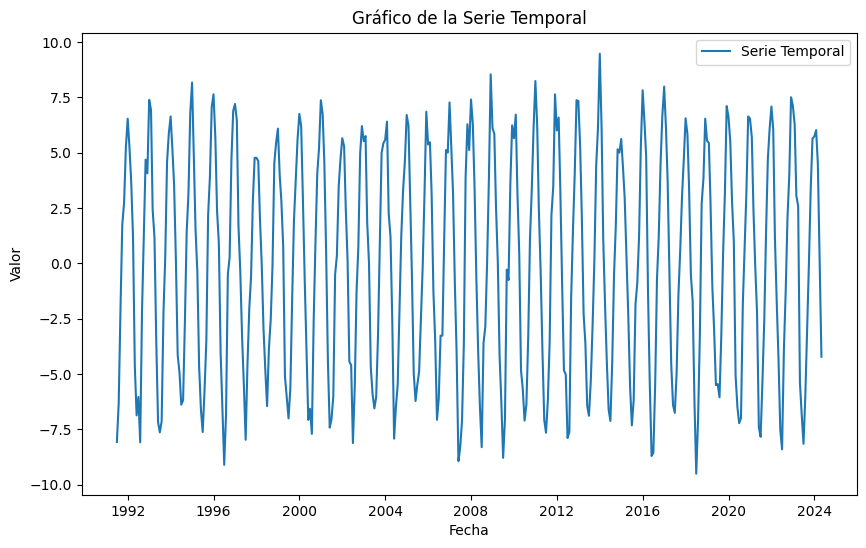

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(datatemperatura_prom_mov.index, datatemperatura_prom_mov['deseasonalized'], label='Serie Temporal')
plt.title('Gráfico de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
X_prom_mov = datatemperatura_prom_mov[['deseasonalized' ]]
train_prom_mov, test_prom_mov = X_prom_mov[0:-24], X_prom_mov[-24:]
train_prom_mov.head()

,deseasonalized
Dias,
1991-06-30,-8.066667
1991-07-31,-6.316667
1991-08-31,-2.000000
1991-09-30,1.750000
1991-10-31,2.750000


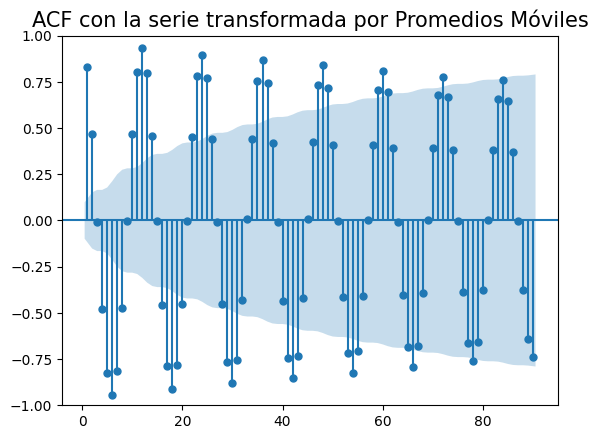

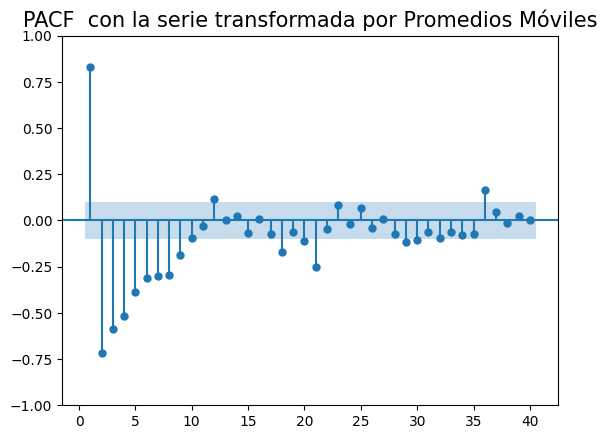

In [ ]:
sgt.plot_acf(datatemperatura_prom_mov.deseasonalized , zero = False, lags = 90)
plt.title("ACF con la serie transformada por Promedios Móviles", size = 15)
plt.show()

sgt.plot_pacf(datatemperatura_prom_mov.deseasonalized, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF  con la serie transformada por Promedios Móviles", size = 15)
plt.show()

# Sexta transformacion = Diferenciacion de la serie diferenciada

In [ ]:
# Aplicar diferenciación
period = 6  # Período de estacionalidad (diferenciación cada 6 periodos)

datatemperatura_dif_dif6 = datatemperatura_dif.copy()
datatemperatura_dif_dif6['Valor_Dif'] = datatemperatura_dif_dif6['Media'].diff(periods=period)

In [ ]:
datatemperatura_dif_dif6.head(7)

,Media,Maxima,Minima,Valor_Dif
Dias,,,,
1991-02-28,22.9,27.8,17.8,NaN
1991-03-31,22.7,27.6,18.4,NaN
1991-04-30,17.8,22.4,13.6,NaN
1991-05-31,16.0,20.7,12.2,NaN
1991-06-30,11.0,14.8,7.6,NaN
1991-07-31,10.5,14.8,6.7,NaN
1991-08-31,13.2,17.1,9.3,-9.7


In [ ]:
indices_a_eliminar = ['1991-02-28','1991-03-31','1991-04-30','1991-05-31','1991-06-30','1991-07-31	']

datatemperatura_dif_dif6 = datatemperatura_dif_dif6.drop(indices_a_eliminar)

In [ ]:
datatemperatura_dif_dif6.head()

,Media,Maxima,Minima,Valor_Dif
Dias,,,,
1991-08-31,13.2,17.1,9.3,-9.7
1991-09-30,15.8,20.5,11.7,-6.9
1991-10-31,16.6,21.1,12.2,-1.2
1991-11-30,19.7,24.3,15.3,3.7
1991-12-31,23.0,27.8,18.7,12.0


In [ ]:
X_diff1_6 = datatemperatura_dif_dif6[['Valor_Dif' ]]
train_diff1_6, test_diff1_16 = X_diff1_6[0:-24], X_diff1_6[-24:]
X_diff1_6.head()

,Valor_Dif
Dias,
1991-08-31,-9.7
1991-09-30,-6.9
1991-10-31,-1.2
1991-11-30,3.7
1991-12-31,12.0


# Septima transfomracion = Diferenciacion cada 6 periodos

In [ ]:
# Aplicar diferenciación estacional
period = 6  # Período de estacionalidad (diferenciación cada 6 periodos)
datatemperatura_dif6 = datatemperatura.copy()
datatemperatura_dif6['Valor_Dif6'] = datatemperatura_dif6['Media'].diff(periods=period)

In [ ]:
datatemperatura_dif6.head(7)

,Media,Maxima,Minima,Valor_Dif6
Dias,,,,
1991-01-31,24.0,28.4,19.8,NaN
1991-02-28,22.9,27.8,17.8,NaN
1991-03-31,22.7,27.6,18.4,NaN
1991-04-30,17.8,22.4,13.6,NaN
1991-05-31,16.0,20.7,12.2,NaN
1991-06-30,11.0,14.8,7.6,NaN
1991-07-31,10.5,14.8,6.7,-13.5


In [ ]:
X_diff1_6 = datatemperatura_dif6[['Valor_Dif6' ]]
train_diff1_6, test_diff1_16 = X_diff1_6[0:-24], X_diff1_6[-24:]
X_diff1_6.head(7)

,Valor_Dif6
Dias,
1991-01-31,NaN
1991-02-28,NaN
1991-03-31,NaN
1991-04-30,NaN
1991-05-31,NaN
1991-06-30,NaN
1991-07-31,-13.5


In [ ]:
indices_a_eliminar = ['1991-01-31'	,'1991-02-28','1991-03-31','1991-04-30','1991-05-31','1991-06-30']

datatemperatura_dif6 = datatemperatura_dif6.drop(indices_a_eliminar)

In [ ]:
datatemperatura_dif6.head()

,Media,Maxima,Minima,Valor_Dif6
Dias,,,,
1991-07-31,10.5,14.8,6.7,-13.5
1991-08-31,13.2,17.1,9.3,-9.7
1991-09-30,15.8,20.5,11.7,-6.9
1991-10-31,16.6,21.1,12.2,-1.2
1991-11-30,19.7,24.3,15.3,3.7


In [ ]:
X_diff6 = datatemperatura_dif6[['Valor_Dif6' ]]
train_diff6, test_diff6 = X_diff6[0:-24], X_diff6[-24:]
X_diff6.head()

,Valor_Dif6
Dias,
1991-07-31,-13.5
1991-08-31,-9.7
1991-09-30,-6.9
1991-10-31,-1.2
1991-11-30,3.7


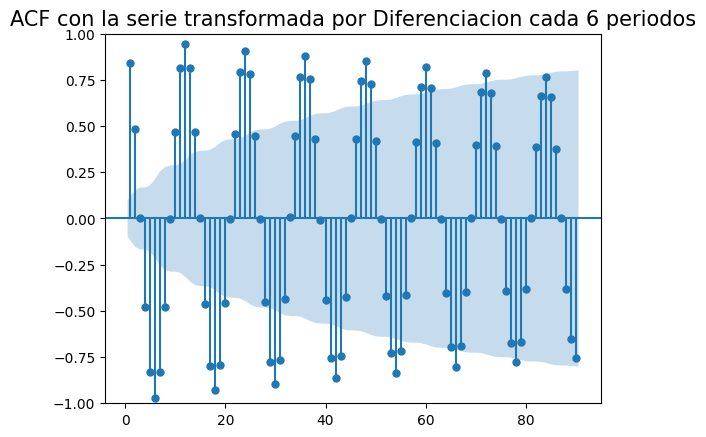

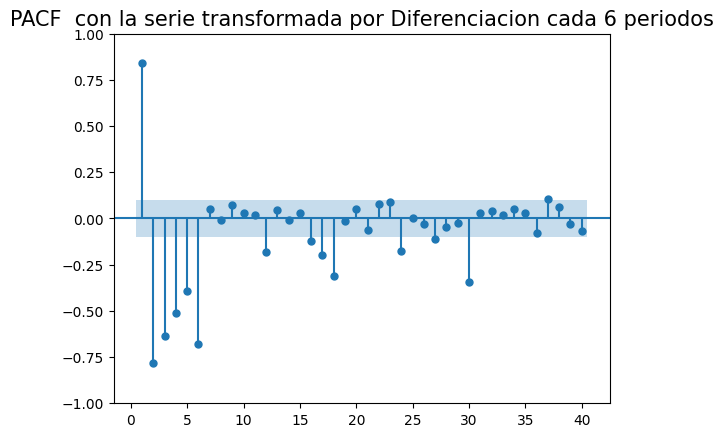

In [ ]:
sgt.plot_acf(datatemperatura_dif6.Valor_Dif6 , zero = False, lags = 90)
plt.title("ACF con la serie transformada por Diferenciacion cada 6 periodos", size = 15)
plt.show()

sgt.plot_pacf(datatemperatura_dif6.Valor_Dif6, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF  con la serie transformada por Diferenciacion cada 6 periodos", size = 15)
plt.show()

# Octava = Diferencia cada 12 periodos (otro metodo)

In [ ]:
# Aplicar diferenciación estacional
period = 12
datatemperatura_dif12 = datatemperatura.copy()
datatemperatura_dif12['Valor_Dif12'] = datatemperatura_dif12['Media'].diff(periods=period)

In [ ]:
datatemperatura_dif12.head(12)

,Media,Maxima,Minima,Valor_Dif12
Dias,,,,
1991-01-31,24.0,28.4,19.8,NaN
1991-02-28,22.9,27.8,17.8,NaN
1991-03-31,22.7,27.6,18.4,NaN
1991-04-30,17.8,22.4,13.6,NaN
1991-05-31,16.0,20.7,12.2,NaN
1991-06-30,11.0,14.8,7.6,NaN
1991-07-31,10.5,14.8,6.7,NaN
1991-08-31,13.2,17.1,9.3,NaN
1991-09-30,15.8,20.5,11.7,NaN


In [ ]:
indices_a_eliminar = ['1991-01-31'	,'1991-02-28','1991-03-31','1991-04-30','1991-05-31','1991-06-30','1991-07-31','1991-08-31','1991-09-30','1991-10-31','1991-11-30','1991-12-31']


datatemperatura_dif12 = datatemperatura_dif12.drop(indices_a_eliminar)

In [ ]:
datatemperatura_dif12.head()

,Media,Maxima,Minima,Valor_Dif12
Dias,,,,
1992-01-31,23.9,28.5,19.8,-0.1
1992-02-29,24.2,29.0,19.8,1.3
1992-03-31,22.9,27.4,18.9,0.2
1992-04-30,17.2,21.9,13.2,-0.6
1992-05-31,14.0,18.5,10.1,-2.0


In [ ]:
datatemperatura_dif12 = datatemperatura_dif12[['Valor_Dif12' ]]
train_diff12, test_diff12 = datatemperatura_dif12[0:-24], datatemperatura_dif12[-24:]
datatemperatura_dif12.head()

,Valor_Dif12
Dias,
1992-01-31,-0.1
1992-02-29,1.3
1992-03-31,0.2
1992-04-30,-0.6
1992-05-31,-2.0


# Corremos Modelos

In [ ]:
from itertools import product

# Modelo - Con los datos transformados en la segunda tranformacion realizada.

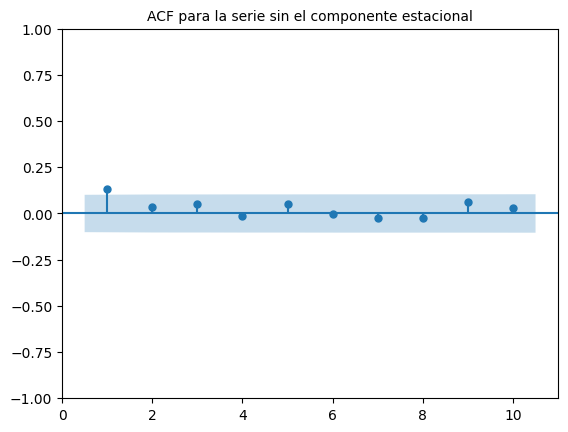

In [ ]:
sgt.plot_acf(train_3.deseasonalizada , zero = False, lags = 10)
plt.title("ACF para la serie sin el componente estacional", size = 10)
plt.show()

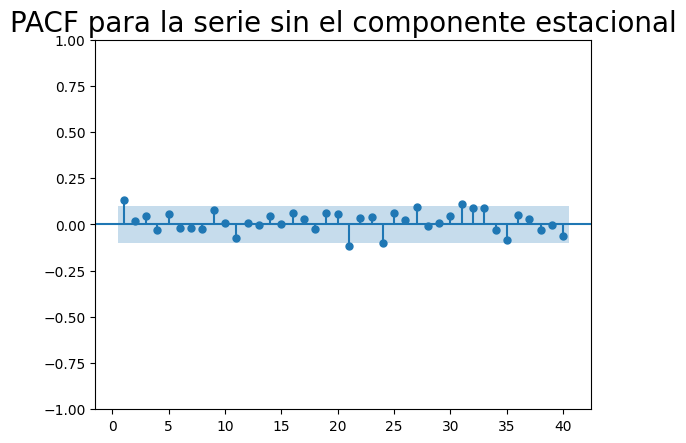

In [ ]:
sgt.plot_pacf(train_3.deseasonalizada, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF para la serie sin el componente estacional", size = 20)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Aca ponemos la serie que queremos analizar.
serie = train_3['deseasonalizada'].dropna()

# Corremos el test de ADF
resultado_adf = adfuller(serie)

# Resultados en pantalla
print("Resultados del test ADF:")
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"Valor-p: {resultado_adf[1]:.4f}")
print(f"Número de observaciones usadas: {resultado_adf[3]}")
print("Valores críticos:")
for clave, valor in resultado_adf[4].items():
    print(f"   {clave}: {valor:.4f}")


if resultado_adf[1] < 0.05:
    print("\n La serie es estacionaria (se rechaza H0 a un nivel de significancia del 5%).")
else:
    print("\n No se puede rechazar H0: la serie NO es estacionaria (a un nivel del 5%).")


Resultados del test ADF:
Estadístico ADF: -16.9160
Valor-p: 0.0000
Número de observaciones usadas: 375
Valores críticos:
   1%: -3.4479
   5%: -2.8693
   10%: -2.5709

 La serie es estacionaria (se rechaza H0 a un nivel de significancia del 5%).


In [ ]:
# Misma forma de ver el test, con otro codigo.
Augmented_Dickey_Fuller_Test_func(train_3['deseasonalizada'],'deseasonalizada')

Results of Dickey-Fuller Test for column: deseasonalizada
Test Statistic                -1.691600e+01
p-value                        1.002311e-29
No Lags Used                   0.000000e+00
Number of Observations Used    3.750000e+02
Critical Value (1%)           -3.447909e+00
Critical Value (5%)           -2.869278e+00
Critical Value (10%)          -2.570892e+00
dtype: float64
Conclusion:====>
Reject the null hypothesis
Data is stationary


In [ ]:
from statsmodels.tsa.stattools import adfuller

def estimar_d_adf(serie, max_d=3, alpha=0.05):

    for d in range(max_d + 1):
        serie_dif = serie.diff(d).dropna() if d > 0 else serie.dropna()
        resultado = adfuller(serie_dif)
        pvalor = resultado[1]
        print(f'd = {d} -> p-valor ADF = {pvalor:.4f}')
        if pvalor < alpha:
            return d
    return max_d  # Si ninguna diferencia alcanza significancia, devolver max_d

# Uso
serie = train_3['deseasonalizada'].dropna()
d_estimado = estimar_d_adf(serie)
print(f'\nEstimacion de d con ADF test : {d_estimado}')


d = 0 -> p-valor ADF = 0.0000

Estimacion de d con ADF test : 0


In [ ]:
from statsmodels.tsa.stattools import kpss

def estimar_d_kpss(serie, max_d=3, alpha=0.05, regression='c'):

    for d in range(max_d + 1):
        serie_dif = serie.diff(d).dropna() if d > 0 else serie.dropna()
        try:
            estadistico, pvalor, _, _ = kpss(serie_dif, regression=regression, nlags='auto')

            if pvalor > alpha:
                return d
        except:
            print(f'd = {d} -> error al ejecutar KPSS')
    return max_d

# Uso
serie = train_3['deseasonalizada'].dropna()
d_estimado = estimar_d_kpss(serie)
print(f'\nEstimación de d con KPSS test : {d_estimado}')


Estimación de d con KPSS test : 1


/tmp/ipykernel_675/2273204325.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  estadistico, pvalor, _, _ = kpss(serie_dif, regression=regression, nlags='auto')
/tmp/ipykernel_675/2273204325.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  estadistico, pvalor, _, _ = kpss(serie_dif, regression=regression, nlags='auto')


In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.3 MB/s eta 0:00:00


In [ ]:
from arch.unitroot import PhillipsPerron
import pandas as pd

def estimar_d_pp_arch(serie, max_d=3, alpha=0.05):
    for d in range(max_d + 1):
        serie_dif = serie.diff(d).dropna() if d > 0 else serie.dropna()
        try:
            resultado = PhillipsPerron(serie_dif)
            pvalor = resultado.pvalue
            print(f'd = {d} -> p-valor PP = {pvalor:.4f}')
            if pvalor < alpha:
                return d  # La serie es estacionaria
        except Exception as e:
            print(f'd = {d} -> error: {e}')
    return max_d

# Ejemplo de uso
serie = train_3['deseasonalizada'].dropna()
d_estimado = estimar_d_pp_arch(serie)
print(f'\nEstimación de d con Phillips-Perron test (libreria usada es la arch): {d_estimado}')


d = 0 -> p-valor PP = 0.0000

Estimación de d con Phillips-Perron test (libreria usada es la arch): 0


Auto Arima con datos trabajados

In [ ]:
stepwise_model1 = auto_arima(train_3.deseasonalizada,max_order= None , d=0,
max_p=4, max_q=4, maxiter= 5000, trace =True ,n_jobs=-1,alpha=0.05)
   # trace=True,suppress_warnings=True)
stepwise_model1.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1130.501, Time=1.64 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1131.016, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1126.331, Time=0.23 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1126.620, Time=0.14 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3248.313, Time=0.05 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1128.169, Time=0.22 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1128.220, Time=0.29 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1130.133, Time=0.37 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 3.051 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  376
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -560.165
Date:                Fri, 13 Mar 2026   AIC                           1126.331
Time:                        16:56:32   BIC                           1138.120
Sample:                    01-31-1991   HQIC                          1131.011
                         - 04-30-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     15.7033      0.940     16.706      0.000      13.861      17.546
ar.L1          0.1326      0.052      2.557      0.011       0.031       0.234
sigma2         1.1522      0.083     13.806      0.000       0.989       1.316
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.11
Prob(Q):                              0.96   Prob(JB):                         0.57
Heteroskedasticity (H):               1.16   Skew:                             0.13
Prob(H) (two-sided):                  0.40   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Modelo - Segun el auto arima

In [ ]:
import statsmodels.api as sm
modelo4 = sm.tsa.arima.ARIMA(train_3.deseasonalizada, order=((1,0,0)))
resultado4 = modelo4.fit()

resultado4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        deseasonalizada   No. Observations:                  376
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -560.165
Date:                Fri, 13 Mar 2026   AIC                           1126.331
Time:                        16:57:35   BIC                           1138.120
Sample:                    01-31-1991   HQIC                          1131.011
                         - 04-30-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.1043      0.064    282.506      0.000      17.979      18.230
ar.L1          0.1327      0.052      2.559      0.010       0.031       0.234
sigma2         1.1522      0.083     13.806      0.000       0.989       1.316
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.11
Prob(Q):                              0.96   Prob(JB):                         0.57
Heteroskedasticity (H):               1.16   Skew:                             0.13
Prob(H) (two-sided):                  0.40   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Analisis de los residuos y proyecciones

Modelo - Segun el auto arima

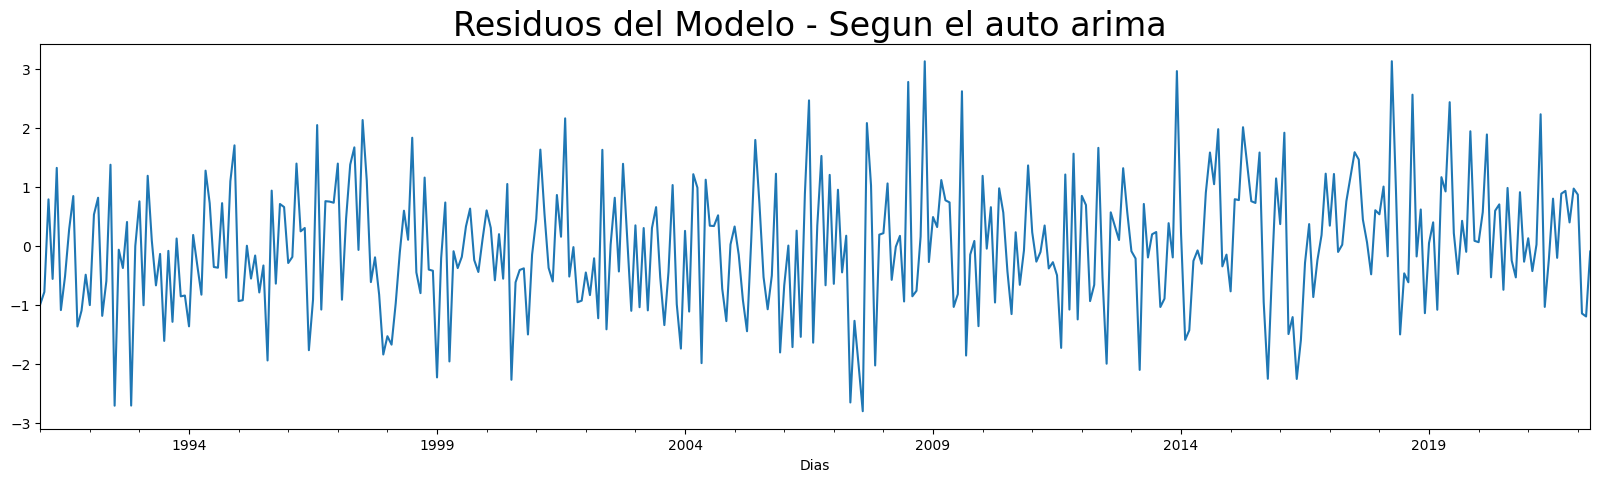

In [ ]:
resultado4.resid.plot(figsize=(20,5))
plt.title("Residuos del Modelo - Segun el auto arima ",size=24)
plt.show()

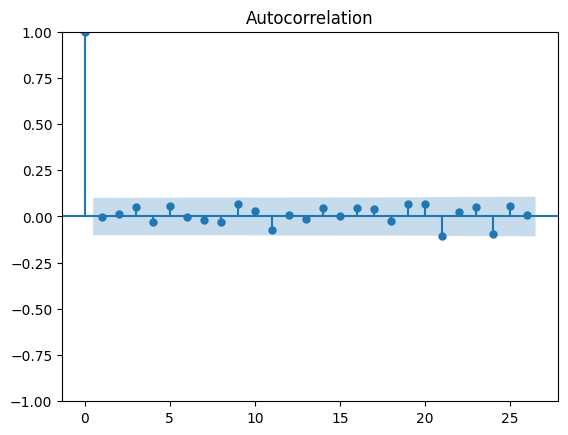

In [ ]:
plot_acf(resultado4.resid);

In [ ]:
import statsmodels.api as sm
Incorr_residuos_modelo4=sm.stats.acorr_ljungbox(resultado4.resid, lags=30)
Incorr_residuos_modelo4

,lb_stat,lb_pvalue
1,0.002711,0.958478
2,0.076518,0.962463
3,1.126286,0.770733
4,1.438508,0.837475
5,2.686419,0.748195
6,2.697491,0.845744
7,2.848323,0.898670
8,3.243705,0.918146
9,4.901016,0.842850
10,5.214470,0.876398


Text(0, 0.5, 'P-valores ')

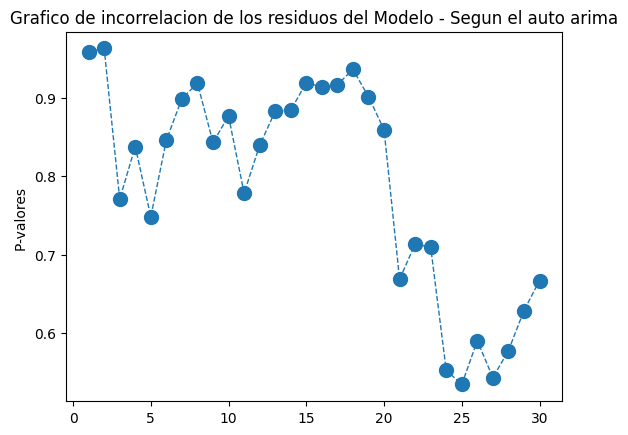

In [ ]:
plt.plot(Incorr_residuos_modelo4.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del Modelo - Segun el auto arima")
plt.ylabel("P-valores ")

In [ ]:
# Pasamos a la prediccion
forecast4 = resultado4.get_forecast(steps=24)

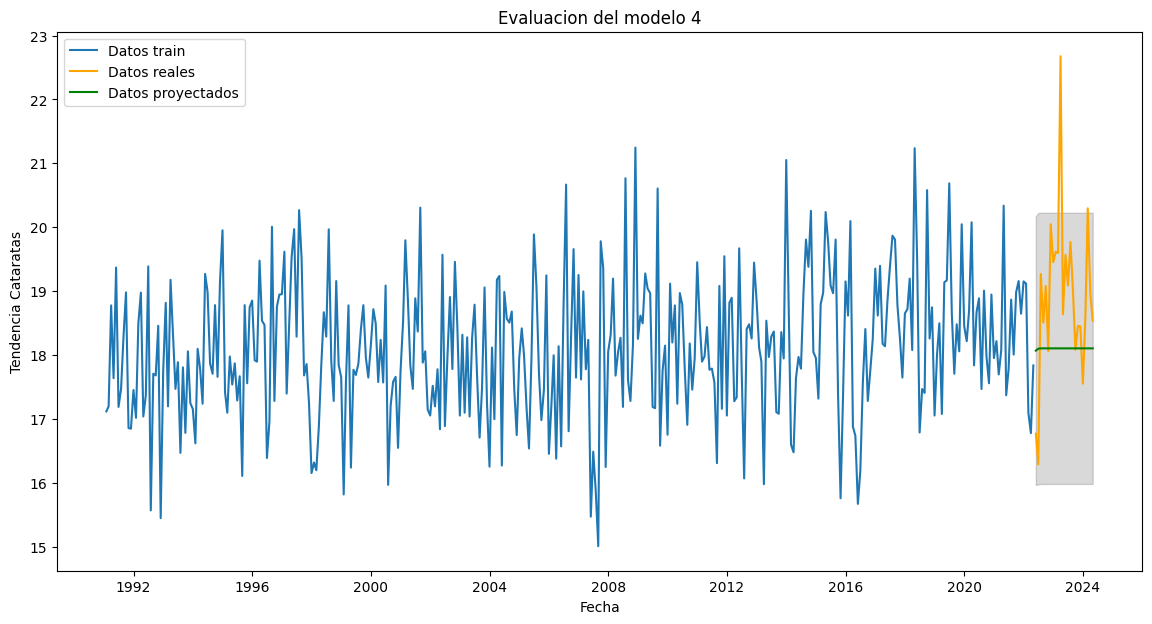

RMSE: 1.4721046784065699
Mean Absolute Error (MAE): 1.1417080916497304
Mean Absolute Percentage Error (MAPE): 0.05865962770171399


In [ ]:
test_forecast_series4 = pd.Series(forecast4.predicted_mean, index=test.index)

mse = mean_squared_error(test_3['deseasonalizada'], test_forecast_series4)
rmse = mse**0.5

plt.figure(figsize=(14,7))
plt.plot(train_3['deseasonalizada'], label='Datos train')
plt.plot(test_3['deseasonalizada'], label='Datos reales', color='orange')
plt.plot(test_forecast_series4, label='Datos proyectados', color='green')
plt.fill_between(test.index,
                 forecast4.conf_int().iloc[:, 0],
                 forecast4.conf_int().iloc[:, 1],
                 color='k', alpha=.15)
plt.title('Evaluacion del modelo 4')
plt.xlabel('Fecha')
plt.ylabel('Tendencia Cataratas')
plt.legend()
plt.show()

print('RMSE:', rmse)

mae = mean_absolute_error(test_3['deseasonalizada'], test_forecast_series4)
r2 = r2_score(test_3['deseasonalizada'], test_forecast_series4)
mape = mean_absolute_percentage_error(test_3['deseasonalizada'], test_forecast_series4)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")

****************************************************************

In [ ]:
stepwise_model1 = auto_arima(train_3.deseasonalizada,max_order= None ,
max_p=4, max_q=4, maxiter= 5000, trace =True ,n_jobs=-1,alpha=0.05)
   # trace=True,suppress_warnings=True)
stepwise_model1.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.63 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1335.016, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1253.904, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.78 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1333.016, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1213.703, Time=0.15 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=1202.355, Time=0.19 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=1184.642, Time=0.19 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.10 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.99 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=1182.642, Time=0.11 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=1200.355, Time=0.09 sec
 ARIMA(4,1,1)(0,0,0)[0]             : AIC=1129.779, Time=0.35 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=1128.641, Time=0.30 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1126.903, T

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  376
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -559.451
Date:                Fri, 13 Mar 2026   AIC                           1124.903
Time:                        17:01:35   BIC                           1136.683
Sample:                    01-31-1991   HQIC                          1129.580
                         - 04-30-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1093      0.052      2.083      0.037       0.006       0.212
ma.L1         -0.9833      0.011    -86.004      0.000      -1.006      -0.961
sigma2         1.1472      0.083     13.788      0.000       0.984       1.310
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.89   Prob(JB):                         0.62
Heteroskedasticity (H):               1.15   Skew:                             0.12
Prob(H) (two-sided):                  0.45   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
import statsmodels.api as sm
modelo__2 = sm.tsa.arima.ARIMA(train_3.deseasonalizada, order=((1,1,1)))
resultado__2 = modelo__2.fit()

resultado__2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        deseasonalizada   No. Observations:                  376
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -559.451
Date:                Fri, 13 Mar 2026   AIC                           1124.903
Time:                        17:02:30   BIC                           1136.683
Sample:                    01-31-1991   HQIC                          1129.580
                         - 04-30-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1093      0.052      2.083      0.037       0.006       0.212
ma.L1         -0.9833      0.011    -86.004      0.000      -1.006      -0.961
sigma2         1.1472      0.083     13.788      0.000       0.984       1.310
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.89   Prob(JB):                         0.62
Heteroskedasticity (H):               1.15   Skew:                             0.12
Prob(H) (two-sided):                  0.45   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

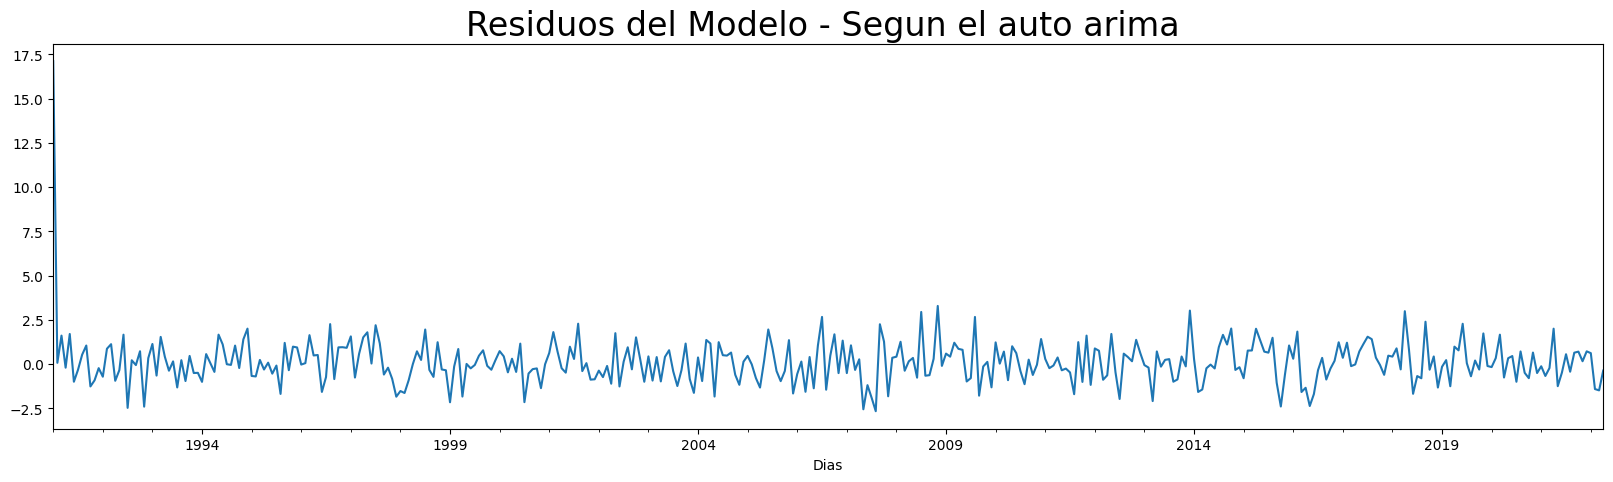

In [ ]:
resultado__2.resid.plot(figsize=(20,5))
plt.title("Residuos del Modelo - Segun el auto arima ",size=24)
plt.show()

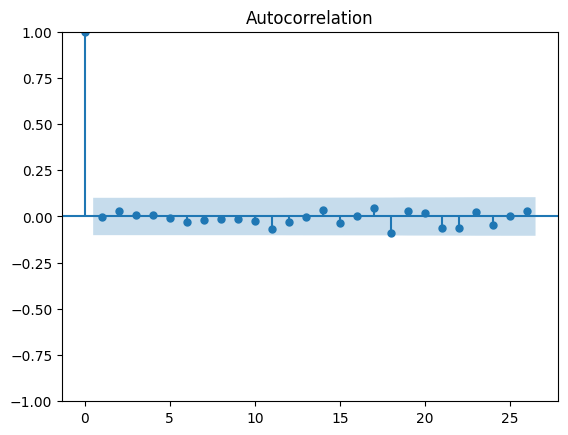

In [ ]:
plot_acf(resultado__2.resid);

In [ ]:
import statsmodels.api as sm
Incorr_residuos_modelo__2=sm.stats.acorr_ljungbox(resultado__2.resid, lags=30)
Incorr_residuos_modelo__2

,lb_stat,lb_pvalue
1,0.011087,0.916143
2,0.372994,0.829861
3,0.391227,0.942049
4,0.402271,0.982291
5,0.444397,0.994018
6,0.773474,0.992766
7,0.903160,0.996243
8,0.981647,0.998362
9,1.029603,0.999366
10,1.251013,0.999524


Text(0, 0.5, 'P-valores ')

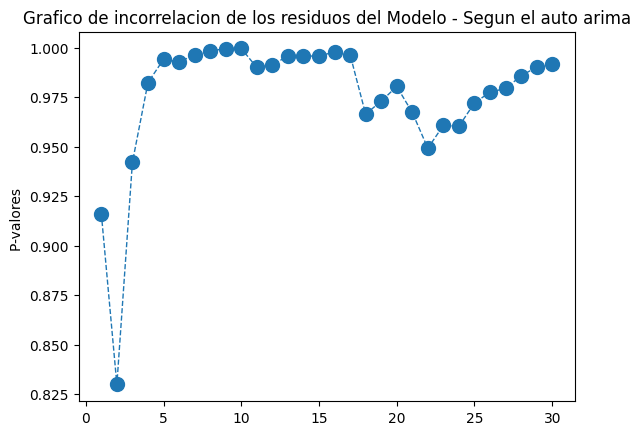

In [ ]:
plt.plot(Incorr_residuos_modelo__2.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del Modelo - Segun el auto arima")
plt.ylabel("P-valores ")

In [ ]:
# Pasamos a la prediccion
forecast__2 = resultado__2.get_forecast(steps=24)

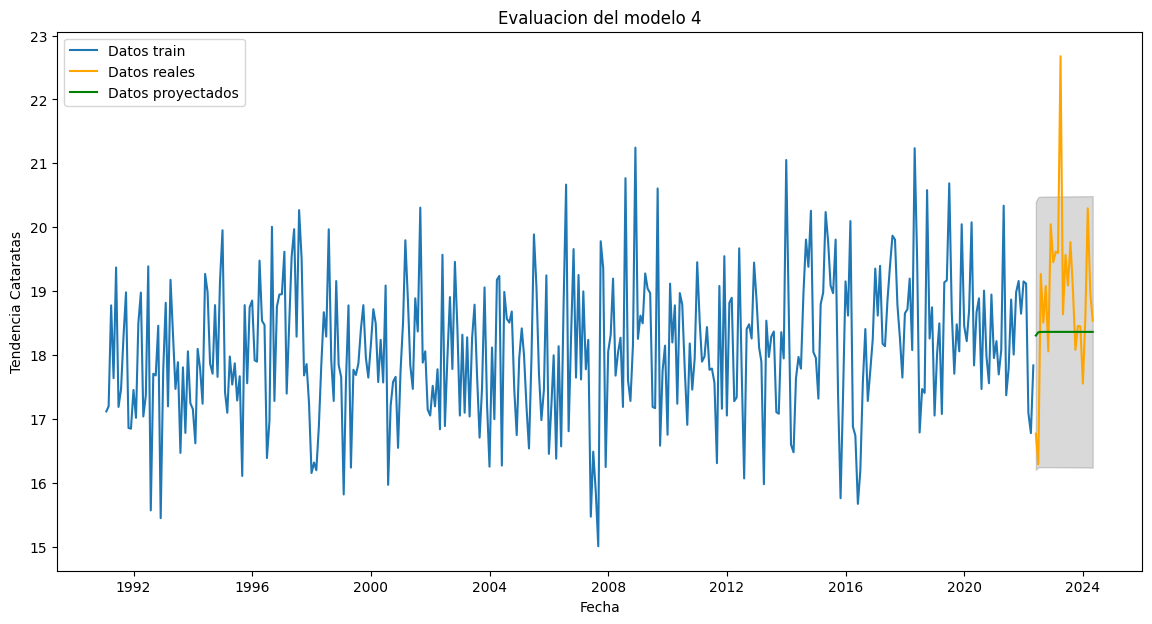

RMSE: 1.3423713353479398
Mean Absolute Error (MAE): 0.9902464489322905
Mean Absolute Percentage Error (MAPE): 0.051126422613459226


In [ ]:
test_forecast_series__2 = pd.Series(forecast__2.predicted_mean, index=test.index)

mse = mean_squared_error(test_3['deseasonalizada'], test_forecast_series__2)
rmse = mse**0.5

plt.figure(figsize=(14,7))
plt.plot(train_3['deseasonalizada'], label='Datos train')
plt.plot(test_3['deseasonalizada'], label='Datos reales', color='orange')
plt.plot(test_forecast_series__2, label='Datos proyectados', color='green')
plt.fill_between(test.index,
                 forecast__2.conf_int().iloc[:, 0],
                 forecast__2.conf_int().iloc[:, 1],
                 color='k', alpha=.15)
plt.title('Evaluacion del modelo 4')
plt.xlabel('Fecha')
plt.ylabel('Tendencia Cataratas')
plt.legend()
plt.show()

print('RMSE:', rmse)

mae = mean_absolute_error(test_3['deseasonalizada'], test_forecast_series__2)
r2 = r2_score(test_3['deseasonalizada'], test_forecast_series__2)
mape = mean_absolute_percentage_error(test_3['deseasonalizada'], test_forecast_series__2)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")

FIN DEL CODIGO